# Lab 02 - Data Understanding: LLM Hallucination

This notebook applies **Lab 2 - Data Understanding** to the assignment dataset. The goal is to become familiar with the data through dataframe inspection, category counts, and visual exploration.


## Lab 2 concepts used

- Import pandas, seaborn, matplotlib, and warnings.
- Use `head()` and `tail()` to inspect rows.
- Use `value_counts()` to understand important categories or labels.
- Create scatter, jointplot, hue-based scatter, boxplot, stripplot, KDE, pairplot, grouped boxplot, and radviz visualizations where suitable for the dataset.


In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


In [2]:
from pathlib import Path
PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != 'AML Assignment' and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
PROJECT_ROOT


WindowsPath('D:/APU Study/1st Semester/Applied Machine Learning/AML Assignment')

In [3]:
DATASET_FILENAME = 'llm_hallucination_dataset_v1.csv'
matches = sorted((PROJECT_ROOT / 'Datasets').glob(f'*/{DATASET_FILENAME}'))
if not matches:
    raise FileNotFoundError(f'Could not find {DATASET_FILENAME} under {PROJECT_ROOT / "Datasets"}')
DATASET_PATH = matches[0]
data = pd.read_csv(DATASET_PATH)
data['prompt_length'] = data['prompt_text'].fillna('').str.len()
data['response_length'] = data['response_text'].fillna('').str.len()
data['hallucination_label_name'] = data['hallucination_label'].map({0: 'Not hallucinated', 1: 'Hallucinated'})
data.head()


,record_id,created_date,model_name,model_version,prompt_id,prompt_text,prompt_type,response_text,domain,task_type,...,annotator_type,annotation_confidence,mitigation_strategy,mitigation_applied,verified_source,intrinsic_or_extrinsic,notes,prompt_length,response_length,hallucination_label_name
0,70b69889-3b46-4b1e-8f83-b95720bddbcd,2024-11-02,GPT-4o,gpt-4o-2024-11-20,PROMPT_00001,Who invented the telephone?,Multi-Hop,The telephone was invented by Nikola Tesla in ...,History,Question-Answering,...,human_expert,0.73,RAG,True,PubMed,Extrinsic,NaN,27,126,Hallucinated
1,e93f6574-d3a1-4459-9ccc-8615bc2b627f,2024-09-24,Mistral-Large,mistral-large-2411,PROMPT_00002,What is the boiling point of water at sea level?,Multi-Hop,Water boils at 100 degrees Celsius (212 degree...,Science,Question-Answering,...,human_expert,0.88,NaN,False,ArXiv,NaN,NaN,48,109,Not hallucinated
2,fc732394-9369-4811-8484-e07f69cb6fab,2025-01-29,Mistral-Large,mistral-large-2411,PROMPT_00003,What is the recommended first-line treatment f...,Ambiguous,The first-line pharmacological treatment for T...,Medicine,Question-Answering,...,human_expert,0.83,Self-Consistency,True,SEC-Filing,Extrinsic,NaN,65,120,Hallucinated
3,2e488a3d-bfc4-4d1e-b59b-eeca571c9c27,2024-10-26,Llama-3.1-70B,llama-3.1-70b-instruct,PROMPT_00004,When was Apple Inc. founded?,Ambiguous,"Apple Inc. was founded on April 1, 1976, by St...",Finance,Question-Answering,...,human_crowd,0.86,CoT-Prompting,True,PubMed,NaN,NaN,28,88,Not hallucinated
4,eb1c2d1e-9fb6-46f0-9f65-0f36494db9dc,2024-11-07,Gemini-1.5-Pro,gemini-1.5-pro-002,PROMPT_00005,Is it legal to record a phone call without con...,Direct-Factual,"In California, you can legally record a phone ...",Law,Fact-Verification,...,human_expert,0.95,Structured-Prompt,True,Snopes,Extrinsic,NaN,65,131,Hallucinated


In [4]:
data.tail()


,record_id,created_date,model_name,model_version,prompt_id,prompt_text,prompt_type,response_text,domain,task_type,...,annotator_type,annotation_confidence,mitigation_strategy,mitigation_applied,verified_source,intrinsic_or_extrinsic,notes,prompt_length,response_length,hallucination_label_name
195,dc1ddb29-e3d9-4651-a570-c7439d420f95,2025-04-03,GPT-4o,gpt-4o-2024-11-20,PROMPT_00196,When did the Soviet Union collapse?,Ambiguous,The Soviet Union officially dissolved on Decem...,History,Dialogue,...,llm_judge_gpt4o,0.81,NaN,False,Wikipedia,Intrinsic,NaN,35,105,Hallucinated
196,7f2a8697-2deb-4a69-8a08-3802e53886f8,2025-02-26,Gemini-1.5-Pro,gemini-1.5-pro-002,PROMPT_00197,Summarize what a hedge fund does.,Multi-Hop,A hedge fund is a pooled investment vehicle th...,Finance,Summarization,...,human_crowd,0.97,Self-Consistency,True,Human-Expert,Extrinsic,NaN,33,357,Hallucinated
197,c59849f3-99b3-4646-b8c4-9a7904e24e3b,2024-09-05,Mistral-Large,mistral-large-2411,PROMPT_00198,Can you explain what an API is?,Ambiguous,An API (Application Programming Interface) is ...,Technology,Dialogue,...,llm_judge_gpt4o,0.80,NaN,False,Snopes,NaN,NaN,31,245,Not hallucinated
198,a04df3dd-4a1f-4ef8-8d58-04ab3685903d,2024-11-17,GPT-4o,gpt-4o-2024-11-20,PROMPT_00199,Does the MMR vaccine cause autism?,Direct-Factual,No. The claim that the MMR vaccine causes auti...,Medicine,Fact-Verification,...,human_crowd,0.95,CoT-Prompting,True,Human-Expert,NaN,NaN,34,270,Not hallucinated
199,6067be34-d199-4995-a770-cc3501f96725,2025-01-31,GPT-4o,gpt-4o-2024-11-20,PROMPT_00200,What is the chemical formula for table salt?,Long-Context,The chemical formula for table salt is NaCl (s...,General,Question-Answering,...,llm_judge_gpt4o,0.82,Self-Consistency,True,SEC-Filing,NaN,NaN,44,62,Not hallucinated


In [5]:
print('Shape:', data.shape)
print('Columns:')
for column in data.columns:
    print('-', column)


Shape: (200, 28)
Columns:
- record_id
- created_date
- model_name
- model_version
- prompt_id
- prompt_text
- prompt_type
- response_text
- domain
- task_type
- language
- hallucination_label
- hallucination_type
- hallucination_span
- correct_information
- correction_text
- severity
- domain_risk
- annotator_type
- annotation_confidence
- mitigation_strategy
- mitigation_applied
- verified_source
- intrinsic_or_extrinsic
- notes
- prompt_length
- response_length
- hallucination_label_name


In [6]:
print('\nValue counts for model_name')
display(data['model_name'].value_counts(dropna=False).head(15))

print('\nValue counts for domain')
display(data['domain'].value_counts(dropna=False).head(15))

print('\nValue counts for language')
display(data['language'].value_counts(dropna=False).head(15))

print('\nValue counts for hallucination_label')
display(data['hallucination_label'].value_counts(dropna=False).head(15))



Value counts for model_name


model_name
Llama-3.1-70B        48
Mistral-Large        45
GPT-4o               42
Gemini-1.5-Pro       34
Claude-3.5-Sonnet    31
Name: count, dtype: int64


Value counts for domain


domain
Medicine      38
Technology    34
Science       30
Finance       30
History       23
Law           19
General       15
Politics      11
Name: count, dtype: int64


Value counts for language


language
English     117
Spanish      20
Mandarin     16
Arabic       14
French       13
Hindi        11
German        9
Name: count, dtype: int64


Value counts for hallucination_label


hallucination_label
0    131
1     69
Name: count, dtype: int64

## Dataset-adapted Lab 2 visualizations

The original Lab 2 notebook uses Iris features such as sepal length, sepal width, petal length, and species. The cells below keep the same visualization ideas, but use columns that make sense for this dataset.


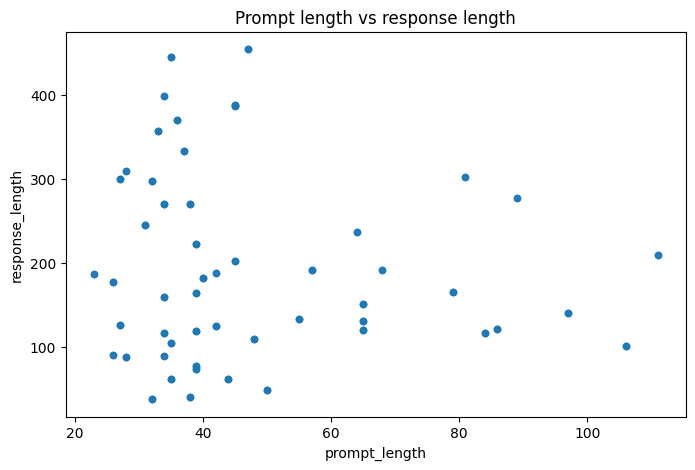

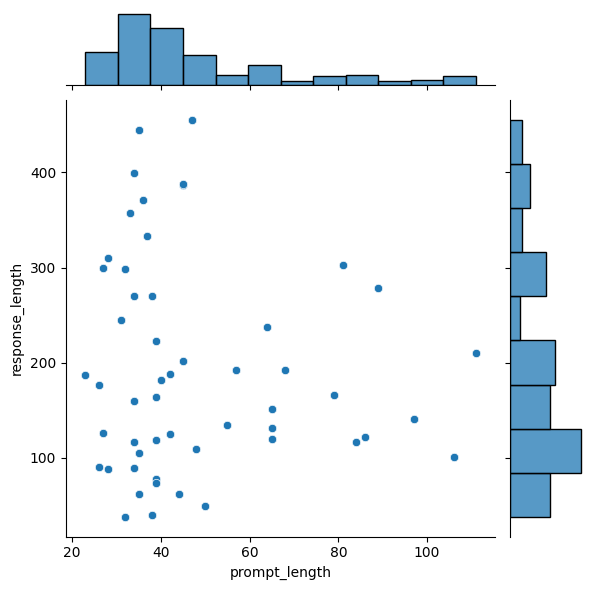

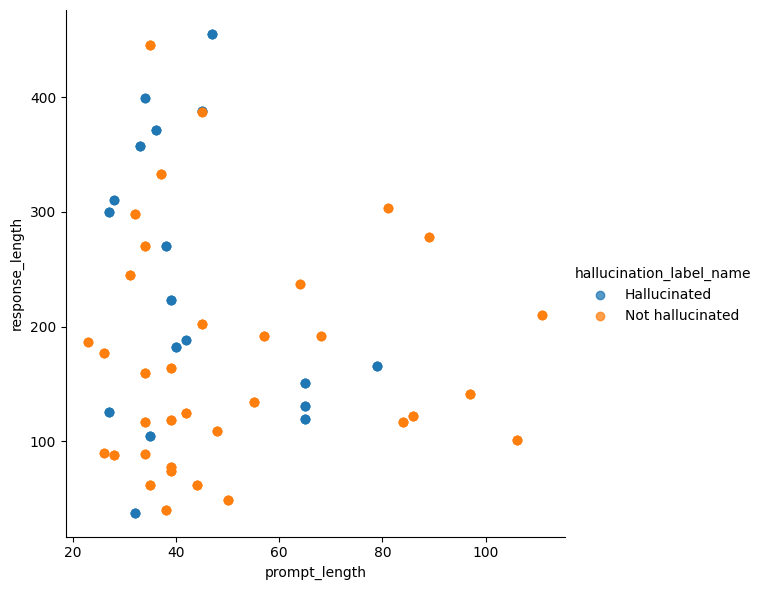

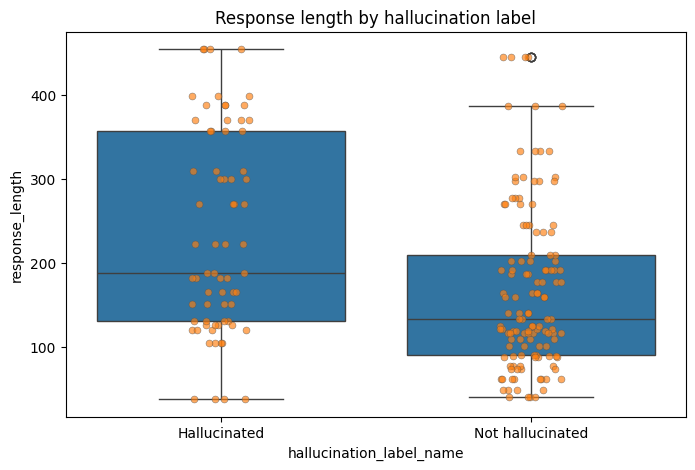

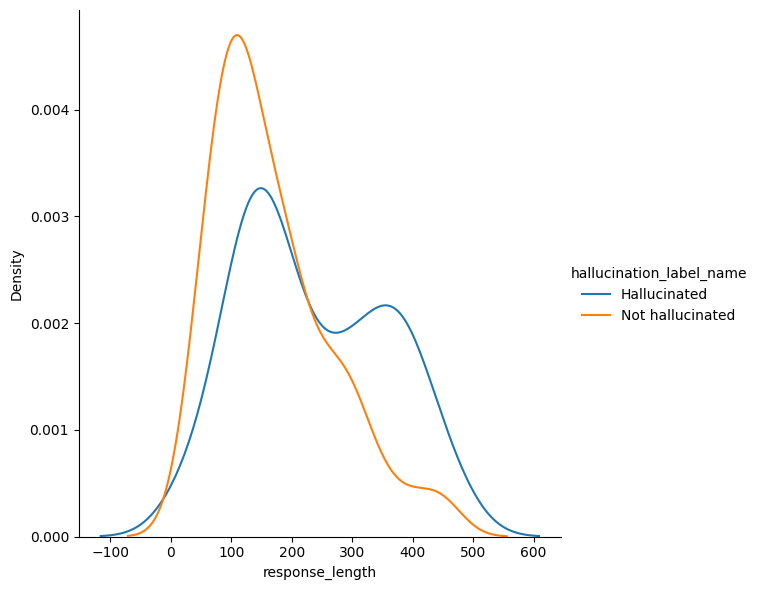

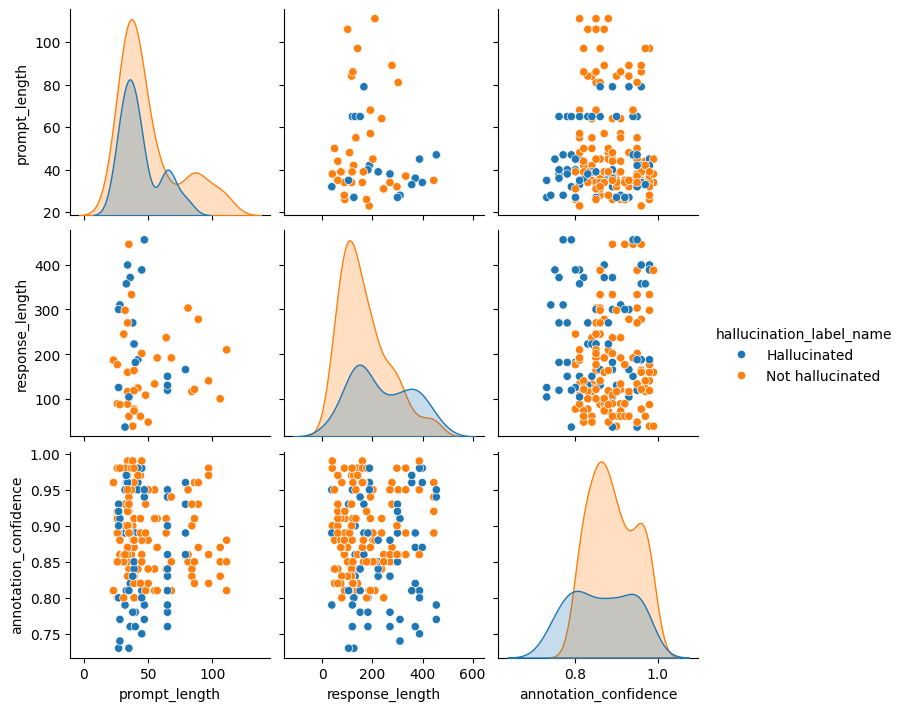

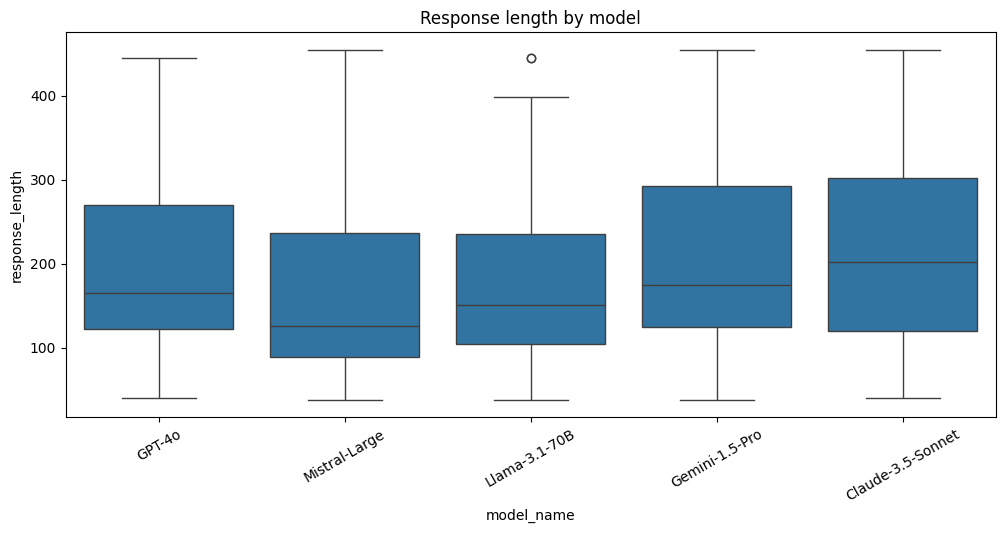

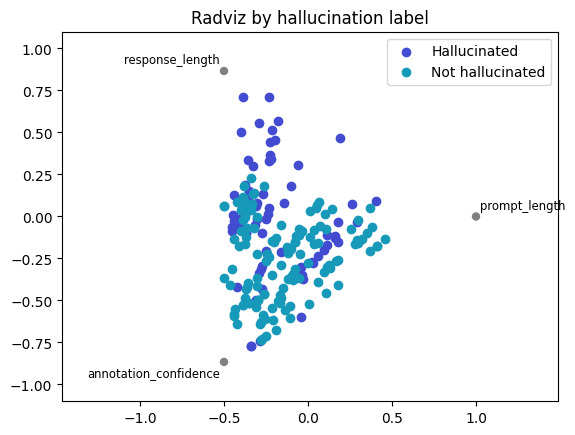

In [7]:
plot_df = data.copy()
plot_df.plot(kind='scatter', x='prompt_length', y='response_length', alpha=0.65, figsize=(8, 5), title='Prompt length vs response length')
plt.show()

sns.jointplot(x='prompt_length', y='response_length', data=plot_df, height=6)
plt.show()

sns.FacetGrid(plot_df, hue='hallucination_label_name', height=6).map(plt.scatter, 'prompt_length', 'response_length', alpha=0.75).add_legend()
plt.show()

plt.figure(figsize=(8, 5))
sns.boxplot(x='hallucination_label_name', y='response_length', data=plot_df)
sns.stripplot(x='hallucination_label_name', y='response_length', data=plot_df, jitter=True, edgecolor='gray', linewidth=0.4, alpha=0.65)
plt.title('Response length by hallucination label')
plt.show()

sns.FacetGrid(plot_df, hue='hallucination_label_name', height=6).map(sns.kdeplot, 'response_length').add_legend()
plt.show()

pair_cols = ['prompt_length', 'response_length', 'annotation_confidence', 'hallucination_label_name']
sns.pairplot(plot_df[pair_cols].dropna(), hue='hallucination_label_name', height=2.4, diag_kind='kde')
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(x='model_name', y='response_length', data=plot_df)
plt.title('Response length by model')
plt.xticks(rotation=30)
plt.show()

from pandas.plotting import radviz
radviz_cols = ['prompt_length', 'response_length', 'annotation_confidence', 'hallucination_label_name']
radviz(plot_df[radviz_cols].dropna(), 'hallucination_label_name')
plt.title('Radviz by hallucination label')
plt.show()


## What was learned from Lab 2

These plots give an initial view of distributions, category balance, relationships between numeric fields, and possible separation by important labels or groups. No preprocessing or machine learning model is applied yet; that begins from Lab 3 onward.
